In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fies_df_2022_1 = pd.read_csv("relatorio_dados_abertos_oferta_12022_15072022.csv", sep=";", encoding="latin-1")
fies_df_2022_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24918 entries, 0 to 24917
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Ano                               24918 non-null  int64 
 1   Semestre                          24918 non-null  int64 
 2   Nome Mantenedora                  24918 non-null  object
 3   Código e-MEC da Mantenedora       24918 non-null  int64 
 4   CNPJ da mantenedora               24918 non-null  int64 
 5   Nome da IES                       24918 non-null  object
 6   Código e-MEC da IES               24918 non-null  int64 
 7   Organização Acadêmica da IES      24918 non-null  object
 8   UF da IES                         24918 non-null  object
 9   Município da IES                  24918 non-null  object
 10  Nome do Local de oferta           24918 non-null  object
 11  Código do Local de Oferta         24918 non-null  int64 
 12  Município do Local

In [5]:
print(fies_df_2022_1.isna().sum())

Ano                                   0
Semestre                              0
Nome Mantenedora                      0
Código e-MEC da Mantenedora           0
CNPJ da mantenedora                   0
Nome da IES                           0
Código e-MEC da IES                   0
Organização Acadêmica da IES          0
UF da IES                             0
Município da IES                      0
Nome do Local de oferta               0
Código do Local de Oferta             0
Município do Local de Oferta          0
UF do Local de Oferta                 0
Nome da Microregião                   0
Código da Microregião                 0
Código da Mesorregião                 0
Nome da Mesorregião                   0
Área do conhecimento                  0
Subárea do conhecimento               0
Cód. Do Grupo de Preferência          0
Nota de Corte GP                    510
Código do Curso                       0
Nome do Curso                         0
Turno                                 0


In [3]:
vg_ocup = fies_df_2022_1["Vagas ocupadas"].sum().astype(int)
vg_ofert = fies_df_2022_1["Vagas ofertadas FIES"].sum().astype(int)
perc = (vg_ocup / vg_ofert) * 100
print(f"Percentual de vagas ocupadas: {perc:.2f}%")
print(f"Vagas ocupadas: {vg_ocup}")
print(f"Vagas ofertadas: {vg_ofert}")

Percentual de vagas ocupadas: 4.76%
Vagas ocupadas: 37998
Vagas ofertadas: 798386


In [12]:
vg_ocup_norte, vg_ofert_norte = 0, 0
vg_ocup_nordeste, vg_ofert_nordeste = 0, 0
vg_ocup_sudeste, vg_ofert_sudeste = 0, 0
vg_ocup_sul, vg_ofert_sul = 0, 0
vg_ocup_centro, vg_ofert_centro = 0, 0

for i in range(27):
    vg_ocup = fies_df_2022_1[fies_df_2022_1["UF do Local de Oferta"] == fies_df_2022_1["UF do Local de Oferta"].unique()[i]]["Vagas ocupadas"].sum().astype(int)
    vg_ofert = fies_df_2022_1[fies_df_2022_1["UF do Local de Oferta"] == fies_df_2022_1["UF do Local de Oferta"].unique()[i]]["Vagas ofertadas FIES"].sum().astype(int)
    if fies_df_2022_1["UF do Local de Oferta"].unique()[i] in ["AC", "AP", "AM", "PA", "RO", "RR", "TO"]:
        vg_ocup_norte += vg_ocup
        vg_ofert_norte += vg_ofert
    elif fies_df_2022_1["UF do Local de Oferta"].unique()[i] in ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"]:
        vg_ocup_nordeste += vg_ocup
        vg_ofert_nordeste += vg_ofert
    elif fies_df_2022_1["UF do Local de Oferta"].unique()[i] in ["ES", "MG", "RJ", "SP"]:
        vg_ocup_sudeste += vg_ocup
        vg_ofert_sudeste += vg_ofert
    elif fies_df_2022_1["UF do Local de Oferta"].unique()[i] in ["PR", "RS", "SC"]:
        vg_ocup_sul += vg_ocup
        vg_ofert_sul += vg_ofert
    elif fies_df_2022_1["UF do Local de Oferta"].unique()[i] in ["DF", "GO", "MT", "MS"]:
        vg_ocup_centro += vg_ocup
        vg_ofert_centro += vg_ofert
        
    perc = (vg_ocup / vg_ofert) * 100
    print(f"Percentual de vagas ocupadas em {fies_df_2022_1['UF do Local de Oferta'].unique()[i]}: {perc:.2f}%")

Percentual de vagas ocupadas em SP: 1.77%
Percentual de vagas ocupadas em BA: 6.11%
Percentual de vagas ocupadas em MS: 7.20%
Percentual de vagas ocupadas em PE: 5.77%
Percentual de vagas ocupadas em AL: 5.12%
Percentual de vagas ocupadas em MG: 6.59%
Percentual de vagas ocupadas em MT: 2.71%
Percentual de vagas ocupadas em RS: 5.19%
Percentual de vagas ocupadas em CE: 14.24%
Percentual de vagas ocupadas em PA: 9.05%
Percentual de vagas ocupadas em GO: 4.04%
Percentual de vagas ocupadas em MA: 9.26%
Percentual de vagas ocupadas em RN: 3.53%
Percentual de vagas ocupadas em PR: 4.49%
Percentual de vagas ocupadas em RR: 3.07%
Percentual de vagas ocupadas em PB: 10.18%
Percentual de vagas ocupadas em AC: 6.44%
Percentual de vagas ocupadas em SC: 2.71%
Percentual de vagas ocupadas em AM: 3.78%
Percentual de vagas ocupadas em ES: 6.69%
Percentual de vagas ocupadas em RJ: 3.20%
Percentual de vagas ocupadas em PI: 16.03%
Percentual de vagas ocupadas em DF: 2.68%
Percentual de vagas ocupadas em

In [13]:
print(f"Percentual de vagas ocupadas na região Norte: {(vg_ocup_norte / vg_ofert_norte) * 100:.2f}%")
print(f"Percentual de vagas ocupadas na região Nordeste: {(vg_ocup_nordeste / vg_ofert_nordeste) * 100:.2f}%")
print(f"Percentual de vagas ocupadas na região Sudeste: {(vg_ocup_sudeste / vg_ofert_sudeste) * 100:.2f}%")
print(f"Percentual de vagas ocupadas na região Sul: {(vg_ocup_sul / vg_ofert_sul) * 100:.2f}%")
print(f"Percentual de vagas ocupadas na região Centro-Oeste: {(vg_ocup_centro / vg_ofert_centro) * 100:.2f}%")

Percentual de vagas ocupadas na região Norte: 6.54%
Percentual de vagas ocupadas na região Nordeste: 8.39%
Percentual de vagas ocupadas na região Sudeste: 2.84%
Percentual de vagas ocupadas na região Sul: 4.38%
Percentual de vagas ocupadas na região Centro-Oeste: 3.52%


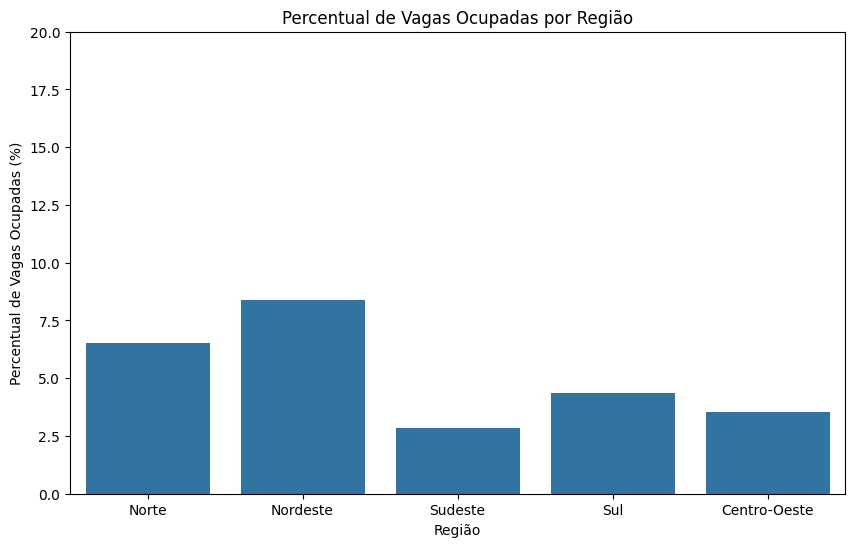

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"], y=[(vg_ocup_norte / vg_ofert_norte) * 100, (vg_ocup_nordeste / vg_ofert_nordeste) * 100, (vg_ocup_sudeste / vg_ofert_sudeste) * 100, (vg_ocup_sul / vg_ofert_sul) * 100, (vg_ocup_centro / vg_ofert_centro) * 100])
plt.title("Percentual de Vagas Ocupadas por Região")
plt.xlabel("Região")
plt.ylabel("Percentual de Vagas Ocupadas (%)")
plt.ylim(0, 20)
plt.show()


In [33]:
fies_df_2022_1.isna().sum()

Ano                                   0
Semestre                              0
Nome Mantenedora                      0
Código e-MEC da Mantenedora           0
CNPJ da mantenedora                   0
Nome da IES                           0
Código e-MEC da IES                   0
Organização Acadêmica da IES          0
UF da IES                             0
Município da IES                      0
Nome do Local de oferta               0
Código do Local de Oferta             0
Município do Local de Oferta          0
UF do Local de Oferta                 0
Nome da Microregião                   0
Código da Microregião                 0
Código da Mesorregião                 0
Nome da Mesorregião                   0
Área do conhecimento                  0
Subárea do conhecimento               0
Cód. Do Grupo de Preferência          0
Nota de Corte GP                    510
Código do Curso                       0
Nome do Curso                         0
Turno                                 0


In [20]:
print(fies_df_2022_1["UF do Local de Oferta"].value_counts().head(10))

UF do Local de Oferta
SP    6688
MG    2268
BA    1930
RJ    1655
PR    1445
CE    1152
PE    1138
RS     965
PA     795
DF     763
Name: count, dtype: int64


In [17]:
print(fies_df_2022_1["Nome da Microregião"].value_counts().head(10))

Nome da Microregião
São Paulo         2908
Rio de Janeiro    1279
Salvador           873
Belo Horizonte     859
Fortaleza          798
Brasília           763
Recife             741
Manaus             687
Curitiba           607
Belém              498
Name: count, dtype: int64


In [32]:
print(fies_df_2022_1["Nome da Mesorregião"].value_counts().head(10))

Nome da Mesorregião
Metropolitana de São Paulo         3851
Metropolitana do Rio de Janeiro    1363
Metropolitana de Belo Horizonte     951
Metropolitana de Salvador           944
Metropolitana de Fortaleza          809
Metropolitana de Recife             767
Distrito Federal                    763
Centro Amazonense                   699
Metropolitana de Curitiba           612
Centro Goiano                       573
Name: count, dtype: int64


In [19]:
print(fies_df_2022_1["Área do conhecimento"].value_counts())

Área do conhecimento
CURSOS NAO PRIORITARIOS                                        11956
CURSOS DA ÁREA DE ENGENHARIA E CIÊNCIA DA COMPUTAÇÃO            5293
CURSOS DA AREA DE SAUDE                                         5282
CURSOS DA ÁREA DE LICENCIATURA, PEDAGOGIA E NORMAL SUPERIOR     2387
Name: count, dtype: int64


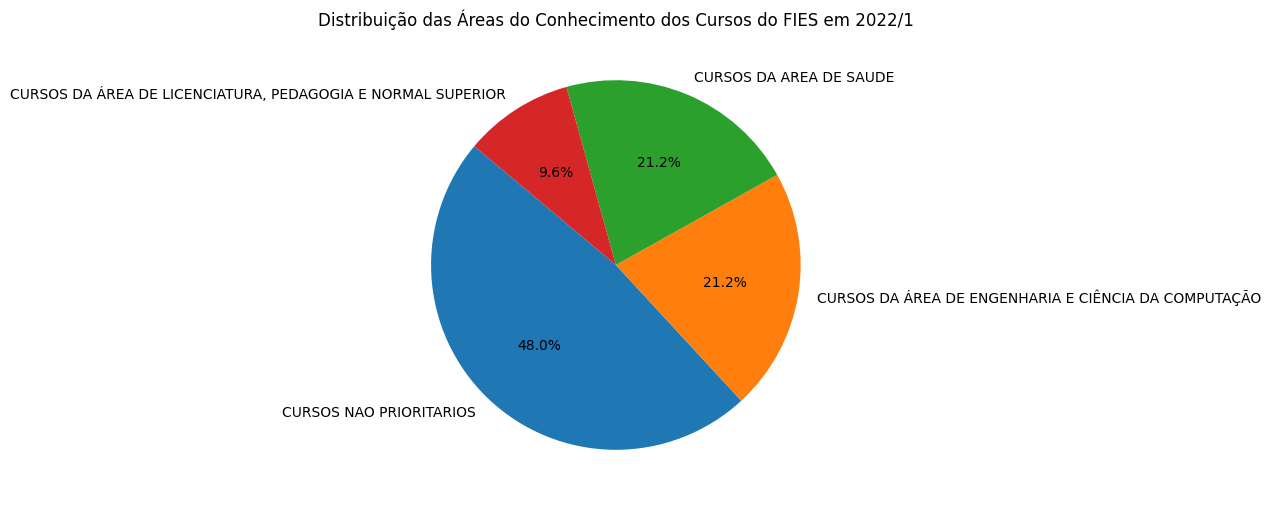

In [7]:
plt.figure(figsize=(10, 6))
# Gráfico de pizza
fies_df_2022_1["Área do conhecimento"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Áreas do Conhecimento dos Cursos do FIES em 2022/1')
plt.ylabel('')
plt.show()

In [22]:
print(fies_df_2022_1["Subárea do conhecimento"].value_counts().head(10))

Subárea do conhecimento
ENFERMAGEM, FISIOTERAPIA, FARMÁCIA, NUTRIÇÃO E CURSOS RELACIONADOS                         3936
ADMINISTRAÇÃO, ADMINISTRAÇÃO PÚBLICA, GESTÃO, LOGÍSTICA, NEGÓCIOS E CURSOS RELACIONADOS    3145
CIÊNCIAS SOCIAIS, POLÍTICAS, ECONÔMICAS E CONTÁBEIS, PSICOLOGIA E SECRETARIADO             2499
DIREITO, COMÉRCIO EXTERIOR, BIBLIOTECONOMIA E CURSOS RELACIONADOS                          2027
ENGENHARIA CIVIL E AMBIENTAL, ARQUITETURA E CURSOS RELACIONADOS                            1641
CIÊNCIA DA COMPUTAÇÃO E SISTEMAS DE INFORMAÇÃO E CURSOS RELACIONADOS                       1365
HISTÓRIA (LIC), GEOGRAFIA (LIC), EDUCAÇÃO FÍSICA (LIC) E CURSOS RELACIONADOS               1185
COMUNICAÇÃO SOCIAL, JORNALISMO, PUBLICIDADE, MARKETING E CURSOS RELACIONADOS                962
CIÊNCIAS BIOLÓGICAS (BEL), BIOMEDICINA, BIOTECNOLOGIA E CURSOS RELACIONADOS                 822
ENGENHARIA ELÉTRICA, ELETRÔNICA, DA COMPUTAÇÃO E CURSOS RELACIONADOS                        806
Name: count, dty

In [24]:
print(fies_df_2022_1["Nome do Curso"].value_counts().head(10))

Nome do Curso
DIREITO               1938
ADMINISTRAÇÃO         1427
ENFERMAGEM            1271
PSICOLOGIA            1242
EDUCAÇÃO FÍSICA       1075
FISIOTERAPIA          1022
CIÊNCIAS CONTÁBEIS     996
ENGENHARIA CIVIL       945
NUTRIÇÃO               845
FARMÁCIA               793
Name: count, dtype: int64


In [26]:
print(fies_df_2022_1["Turno"].value_counts())

Turno
NOTURNO       15786
MATUTINO       7598
VESPERTINO      830
INTEGRAL        704
Name: count, dtype: int64


In [29]:
print(fies_df_2022_1["Grau"].value_counts())

Grau
Bacharelado     18729
Tecnológico      4472
Licenciatura     1717
Name: count, dtype: int64


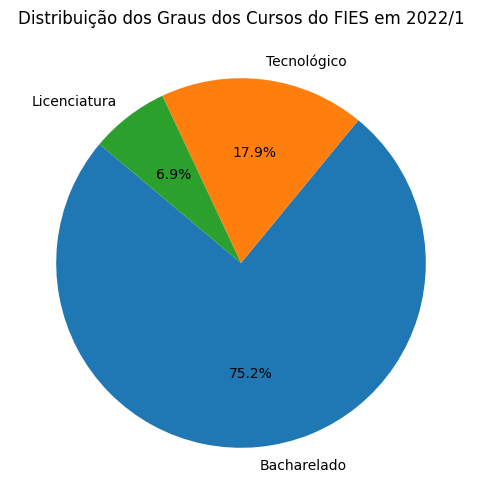

In [6]:
plt.figure(figsize=(10, 6))
fies_df_2022_1["Grau"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição dos Graus dos Cursos do FIES em 2022/1')
plt.ylabel('')
plt.show()

In [31]:
print(fies_df_2022_1["Conceito"].value_counts())

Conceito
4             12063
3              6877
Autorizado     3954
5              2024
Name: count, dtype: int64


In [2]:
fies_alunos_2021_2 = pd.read_csv("relatorio_inscricao_dados_abertos_fies_22021.csv", sep=";", encoding="latin-1")
fies_alunos_2021_2.head()

C:\Users\arfra\AppData\Local\Temp\ipykernel_6344\4085305030.py:1: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  fies_alunos_2021_2 = pd.read_csv("relatorio_inscricao_dados_abertos_fies_22021.csv", sep=";", encoding="latin-1")


,Ano do processo seletivo,Semestre do processo seletivo,Cod. do Grupo de preferência,Classificação,ID do estudante,Sexo,Data de Nascimento,UF de residência,Municipio de residência,Etnia/Cor,...,Ano do Enem,Redação,Matemática e suas Tecnologias,"Linguagens, Códigos e suas Tec",Ciências Natureza e suas Tec,Ciências Humanas e suas Tec,Situação Inscrição Fies,Percentual de financiamento,Semestre do financiamento,Qtde semestre financiado
0,2021,2,125824,24,281805657,M,15/05/2000,PR,COLOMBO,PARDA,...,2020,640,"675,4","643,2","539,7","622,2",NÃO CONTRATADO,NaN,,NaN
1,2021,2,125824,24,281805657,M,15/05/2000,PR,COLOMBO,PARDA,...,2020,640,"675,4","643,2","539,7","622,2",NÃO CONTRATADO,NaN,,NaN
2,2021,2,125824,104,351067941,M,10/07/1994,PR,CURITIBA,BRANCA,...,2011,900,"758,1","646,9","598,4","605,7",PARTICIPACAO CANCELADA PELO CANDIDATO,NaN,,NaN
3,2021,2,125824,34,205906170,M,25/09/1989,PR,CURITIBA,BRANCA,...,2020,540,"609,8","610,7",586,"646,2",OPÇÃO NÃO CONTRATADA,NaN,NaN,10.0
4,2021,2,125824,86,351067085,F,20/07/1999,PR,PARANAGUÁ,BRANCA,...,2017,680,"408,6","499,8","484,5","487,9",NÃO CONTRATADO,NaN,,NaN


In [3]:
fies_alunos_2021_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237965 entries, 0 to 237964
Data columns (total 59 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Ano do processo seletivo              237965 non-null  int64  
 1   Semestre do processo seletivo         237965 non-null  int64  
 2   Cod. do Grupo de preferência          237965 non-null  int64  
 3   Classificação                         237965 non-null  int64  
 4   ID do estudante                       237965 non-null  int64  
 5   Sexo                                  237965 non-null  object 
 6   Data de Nascimento                    237965 non-null  object 
 7   UF de residência                      237965 non-null  object 
 8   Municipio de residência               237965 non-null  object 
 9   Etnia/Cor                             237965 non-null  object 
 10  Pessoa com deficiência?               237965 non-null  object 
 11  